In [1]:
!pip install diffusers transformers accelerate safetensors gradio

In [2]:
import torch
import matplotlib.pyplot as plt
from diffusers import (
    StableDiffusionPipeline,
    DPMSolverMultistepScheduler
)
import gradio as gr

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = 'cpu'
print(device)

cpu


In [5]:
model_id = "runwayml/stable-diffusion-v1-5"


pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float32
)


pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config
)


pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "DPMSolverMultistepScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [6]:
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [7]:
def add_noise(latent, noise, timestep, scheduler):
  noisy_latent = scheduler.add_noise(
      latent,
      noise,
      timestep
  )

  return noisy_latent

In [8]:
prompt = """
A futuristic running shoe,
metallic design,
carbon fiber sole,
premium sports footwear,
studio lighting
"""

In [11]:
text_embeddings = pipe.encode_prompt(
    prompt=prompt,
    device=device,
    num_images_per_prompt=1,
    do_classifier_free_guidance=False
)

text_embeddings

(tensor([[[-0.3884,  0.0229, -0.0522,  ..., -0.4899, -0.3066,  0.0675],
          [ 0.0290, -1.3258,  0.3085,  ..., -0.5257,  0.9768,  0.6652],
          [ 0.1643,  0.0385,  0.7491,  ..., -1.2051, -0.5538,  0.5510],
          ...,
          [ 2.0841,  1.1887, -0.5400,  ..., -2.2322, -0.6403,  0.1764],
          [ 2.0872,  1.1874, -0.5362,  ..., -2.2247, -0.6353,  0.1852],
          [ 2.0883,  1.1254, -0.5134,  ..., -2.2767, -0.6523,  0.1078]]],
        grad_fn=<ViewBackward0>),
 None)

In [12]:
prompt = """
A luxury futuristic sneaker,
black and red color,
carbon fiber texture,
high performance running shoe,
realistic product photography
"""

In [13]:
image = pipe(
    prompt,
    height=256,
    width=256,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

  0%|          | 0/25 [00:00<?, ?it/s]

In [15]:
def generate_shoe(prompt):

    image = pipe(
        prompt,
        height=256,
        width=256,
        num_inference_steps=20,
        guidance_scale=7
    ).images[0]


    return image

  0%|          | 0/20 [00:00<?, ?it/s]

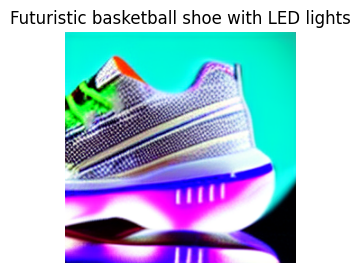

  0%|          | 0/20 [00:00<?, ?it/s]

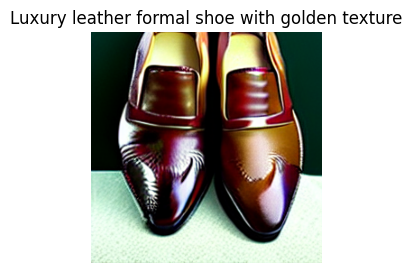

  0%|          | 0/20 [00:00<?, ?it/s]

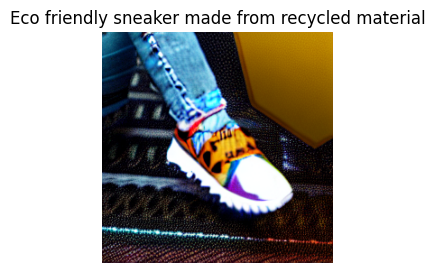

  0%|          | 0/20 [00:00<?, ?it/s]

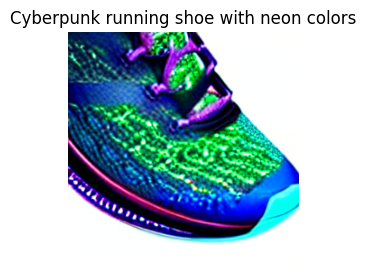

In [16]:
prompts=[
"Futuristic basketball shoe with LED lights",
"Luxury leather formal shoe with golden texture",
"Eco friendly sneaker made from recycled material",
"Cyberpunk running shoe with neon colors"
]


for p in prompts:

    img=generate_shoe(p)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(p)
    plt.axis("off")
    plt.show()

In [17]:
interface = gr.Interface(

    fn=generate_shoe,

    inputs=
    gr.Textbox(
        label="Describe your shoe design"
    ),

    outputs=
    gr.Image(
        label="Generated Shoe"
    ),

    title="AI Shoe Design Generator",

    description=
    """
    Generate customized footwear designs
    using Latent Diffusion Model.
    """

)


interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a1469ae680d525cbf7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
